Data: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

In [229]:
# Handling warnings
import warnings
warnings.filterwarnings("ignore")

In [230]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Customer Churn Data

Q1. Load & Inspect
Download using the link above

Load into pandas, then print:

df.shape

df.dtypes

df.head()

In [231]:
# Loading data
data = pd.read_csv('Telco-Customer-Churn.csv')

In [232]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [233]:
# Dimensions of data
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")
data.info()

Number of rows: 7043
Number of columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16 

Q2. Data Type Conversion

Identify numeric, categorical, boolean columns

Convert:

TotalCharges → numeric (deal with invalid entries)

Other categorical columns → category dtype

In [234]:
# Checking individual column to infer the type
for column in data.columns:
    print(f"{column}: {data[column].unique()}\n")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender: ['Female' 'Male']

SeniorCitizen: [0 1]

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank tra

### Converting data types to categorical

In [235]:
# gender
data.gender = data.gender.astype('category')
# SeniorCitizen
data.SeniorCitizen = data.SeniorCitizen.astype('category')
# Partner
data.Partner = data.Partner.astype('category')
# Dependents
data.Dependents = data.Dependents.astype('category')
# PhoneService
data.PhoneService = data.PhoneService.astype('category')
# MultipleLines
data.MultipleLines = data.MultipleLines.astype('category')
# InternetService
data.InternetService = data.InternetService.astype('category')
# OnlineSecurity
data.OnlineSecurity = data.OnlineSecurity.astype('category')
# OnlineBackup
data.OnlineBackup = data.OnlineBackup.astype('category')
# DeviceProtection
data.DeviceProtection = data.DeviceProtection.astype('category')
# TechSupport
data.TechSupport = data.TechSupport.astype('category')
# StreamingTV
data.StreamingTV = data.StreamingTV.astype('category')
# StreamingMovies
data.StreamingMovies = data.StreamingMovies.astype('category')
# Contract
data.Contract = data.Contract.astype('category')
# PaperlessBilling
data.PaperlessBilling = data.PaperlessBilling.astype('category')
# PaymentMethod
data.PaymentMethod = data.PaymentMethod.astype('category')
# Churn
data.Churn = data.Churn.astype('category')

In [236]:
data.dtypes

customerID            object
gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges          object
Churn               category
dtype: object

Q3. Univariate Analysis

Plot distributions for:

MonthlyCharges

TotalCharges

Churn (countplot)

Also show countplots for:

Contract

InternetService

In [237]:
data.TotalCharges = data.TotalCharges.str.strip()
data.loc[data.TotalCharges == '', 'TotalCharges'] = np.NaN
data.TotalCharges = data.TotalCharges.astype('float')

In [238]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 n

### Distributions for MonthlyCharges and TotalCharges

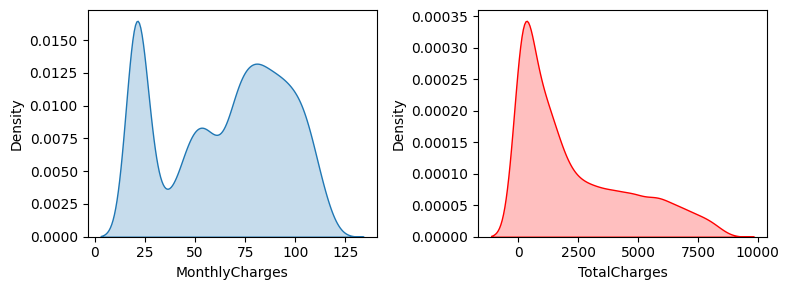

In [239]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
sns.kdeplot(data=data, x='MonthlyCharges', fill=True)
plt.subplot(1,2,2)
sns.kdeplot(data=data, x='TotalCharges', fill=True, color='red')
plt.tight_layout()
plt.show()

In [240]:
# TotalCharges is right skewed
# MonthlyCharges has a very odd distribution, needs further analysis

In [241]:
# Analyzing Skewness in MonthlyCharges

print(f"Mean MonthlyCharges: {data.MonthlyCharges.mean()}")
print(f"Median MonthlyCharges: {data.MonthlyCharges.median()}")

Mean MonthlyCharges: 64.76169246059918
Median MonthlyCharges: 70.35


Mean is less than Median, though not too far, suggesting some left skewness

In [242]:
# Calculating skewness
skw = data.MonthlyCharges.skew()
if skw == 0:
    print(f"{skw}: No skewness.")
elif skw > -1 and skw < 0:
    print(f"{skw}: Moderately left skewed.")
elif skw > 0 and skw < 1:
    print(f"{skw}: Moderately right skewed.")
elif skw >= 1:
    print(f"{skw}: Highly right skewed.")
elif skw <= -1:
    print(f"{skw}: Highly left skewed.")

-0.22052443394398033: Moderately left skewed.


Plotting Churn, Contract, InternetService

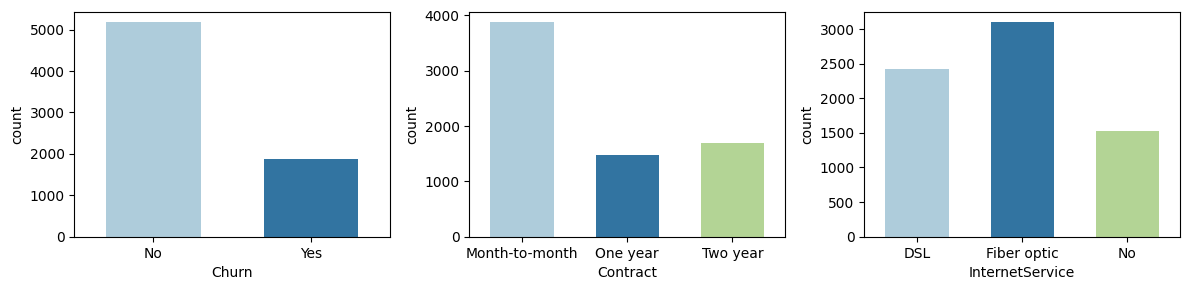

In [243]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
sns.countplot(data=data, x='Churn', width=0.6, palette='Paired')
plt.subplot(1,3,2)
sns.countplot(data=data, x='Contract', width=0.6, palette='Paired')
plt.subplot(1,3,3)
sns.countplot(data=data, x='InternetService', width=0.6, palette='Paired')
plt.tight_layout()
plt.show()

Q4. Clean Dirty Data

Find entries in TotalCharges that couldn’t convert

Impute or drop these invalid rows, then report how many were affected

In [244]:
# TotalCharges data type has been converted already
# Analyzing missing values

data.TotalCharges.isna().sum()

11

In [245]:
# dropping missing values
data.shape[0] - data.dropna(subset=['TotalCharges']).shape[0]
print(f"{data.shape[0] - data.dropna(subset=['TotalCharges']).shape[0]} rows were impacted")
data.dropna(subset=['TotalCharges'], inplace=True)

11 rows were impacted


Q5. Bivariate Analysis

Boxplot: MonthlyCharges vs Churn

Countplot: Contract vs Churn

Compute churn rate by PaymentMethod using grouped means

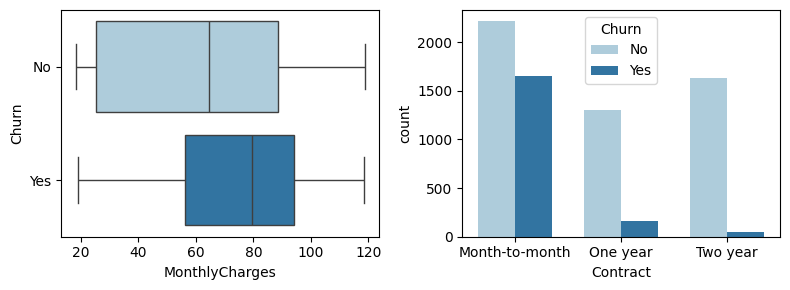

In [246]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
sns.boxplot(data=data, x='MonthlyCharges', y='Churn',  palette='Paired')
plt.subplot(1,2,2)
sns.countplot(data=data, x='Contract', hue='Churn', width=0.7, palette='Paired')
plt.tight_layout()
plt.show()

In [247]:
pm_agg = data.groupby('PaymentMethod').agg({'Churn': 'count'})

In [248]:
pm_agg.Churn/pm_agg.Churn.sum()

PaymentMethod
Bank transfer (automatic)    0.219283
Credit card (automatic)      0.216297
Electronic check             0.336320
Mailed check                 0.228100
Name: Churn, dtype: float64

Q6. Chi-Square Test

Test independence between Contract and Churn

Build contingency table, run chi2_contingency

Report test statistic, p‑value, and conclusion at α = 0.05

In [249]:
from scipy.stats import chi2_contingency

Defining Null Hypothesis H0: Churn is independent of the Contract type and any difference is by chance alone

In [250]:
contingency_matrix = pd.crosstab(data.Contract, data.Churn)

In [251]:
stat, p, dof, expected = chi2_contingency(contingency_matrix)

In [252]:
print(f"Chi-Square statistic: {stat}")
print(f"p-value: {p:10f}")
print(f"Degree of freedom: {dof}")
print(f"Expected frequencies: {expected}")
print(f"{'H0 Rejected, p-value is less than 0.05, the Contract and Churn are dependent' if p < 0.05 else 'H0 Accepted'}")

Chi-Square statistic: 1179.5458287339445
p-value:   0.000000
Degree of freedom: 2
Expected frequencies: [[2845.08319113 1029.91680887]
 [1080.76450512  391.23549488]
 [1237.15230375  447.84769625]]
H0 Rejected, p-value is less than 0.05, the Contract and Churn are dependent


Q7. Prepare Clean Dataset

Create cleaned DataFrame ready for modeling

(Optional) Save as: df.to_csv('telco_clean.csv', index=False)



In [253]:
data.to_csv('telco_clean.csv', index=False)